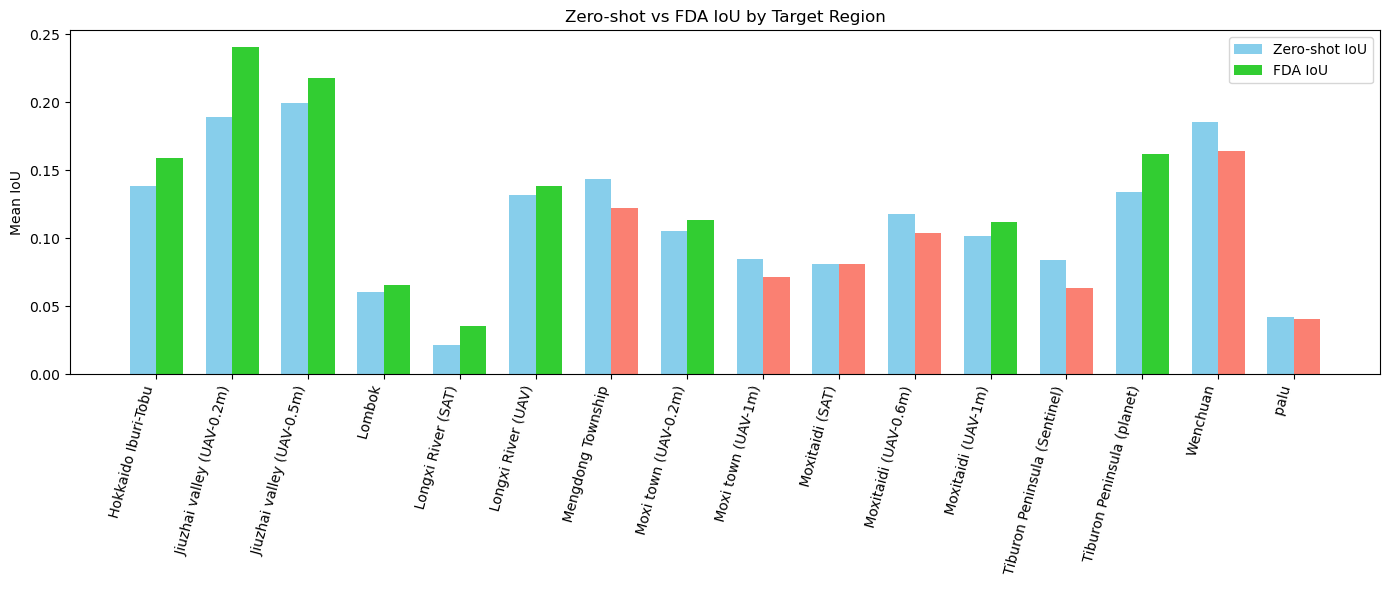

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

zero = pd.read_csv("../../results/new_fda/01_new.csv")
fda = pd.read_csv("../../results/new_fda/01.csv")

zero = zero.add_suffix("_zero")
fda = fda.add_suffix("_fda")

merged = pd.merge(
    zero,
    fda,
    left_on=["source_region_zero", "target_region_zero"],
    right_on=["source_region_fda", "target_region_fda"],
    how="inner"
)

merged["pair"] = merged["source_region_zero"] + " → " + merged["target_region_zero"]
merged["iou_zero"] = merged["iou_zero"]
merged["iou_fda"] = merged["iou_fda"]

grouped = merged.groupby("target_region_zero")[["iou_zero", "iou_fda"]].mean().reset_index()

grouped["better_fda"] = grouped["iou_fda"] > grouped["iou_zero"]

plt.figure(figsize=(14, 6))
bar_width = 0.35
x = range(len(grouped))

plt.bar([i - bar_width/2 for i in x],
        grouped["iou_zero"], width=bar_width, label="Zero-shot IoU", color="skyblue")

colors = ["limegreen" if b else "salmon" for b in grouped["better_fda"]]
plt.bar([i + bar_width/2 for i in x],
        grouped["iou_fda"], width=bar_width, label="FDA IoU", color=colors)

plt.xticks(x, grouped["target_region_zero"], rotation=75, ha="right")
plt.ylabel("Mean IoU")
plt.title("Zero-shot vs FDA IoU by Target Region")
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
import os

files = ["baseline/source_only_100.csv", "new_fda/01.csv", "new_fda/05.csv", "new_fda/09.csv"]
base_path = "../../results/"

dfs = []

for f in files:
    df = pd.read_csv(base_path + f)
    filtered = df[df["target_region"] == " Longxi River (UAV)"][["source_region", "iou"]]
    label = os.path.splitext(os.path.basename(f))[0]
    filtered = filtered.rename(columns={"iou": label})
    dfs.append(filtered)

result = dfs[0]
for d in dfs[1:]:
    result = pd.merge(result, d, on="source_region", how="outer")

print(result)

                   source_region  source_only_100      01      05      09
0            Hokkaido Iburi-Tobu           0.0781  0.0174  0.0559  0.1563
1      Jiuzhai valley (UAV-0.2m)           0.3147  0.2675  0.3156  0.3305
2      Jiuzhai valley (UAV-0.5m)           0.2464  0.2297  0.3150  0.3763
3                         Lombok           0.0663  0.0377  0.0429  0.0447
4             Longxi River (SAT)           0.0324  0.0175  0.0000  0.1066
5              Mengdong Township           0.0782  0.0059  0.0182  0.0091
6           Moxi town (UAV-0.2m)           0.0126  0.3205  0.1715  0.2130
7             Moxi town (UAV-1m)           0.0683  0.1838  0.1413  0.2995
8                Moxitaidi (SAT)           0.1773  0.3440  0.1915  0.2082
9           Moxitaidi (UAV-0.6m)           0.0407  0.2440  0.1871  0.3732
10            Moxitaidi (UAV-1m)           0.0550  0.1359  0.2867  0.2405
11  Tiburon Peninsula (Sentinel)           0.0071  0.0124  0.0169  0.0506
12    Tiburon Peninsula (planet)      

In [16]:
import pandas as pd

df = pd.read_csv("../../results/baseline/source_only_100.csv")

filtered_df = df[df["target_region"] == " Longxi River (UAV)"]
result = filtered_df[["source_region", "iou"]]
print(result)

                    source_region     iou
4             Hokkaido Iburi-Tobu  0.0781
19      Jiuzhai valley (UAV-0.2m)  0.3147
34      Jiuzhai valley (UAV-0.5m)  0.2464
49                         Lombok  0.0663
64             Longxi River (SAT)  0.0324
95              Mengdong Township  0.0782
110          Moxi town (UAV-0.2m)  0.0126
125            Moxi town (UAV-1m)  0.0683
140               Moxitaidi (SAT)  0.1773
155          Moxitaidi (UAV-0.6m)  0.0407
170            Moxitaidi (UAV-1m)  0.0550
185                          palu  0.0041
200    Tiburon Peninsula (planet)  0.1292
215  Tiburon Peninsula (Sentinel)  0.0071
230                      Wenchuan  0.2218


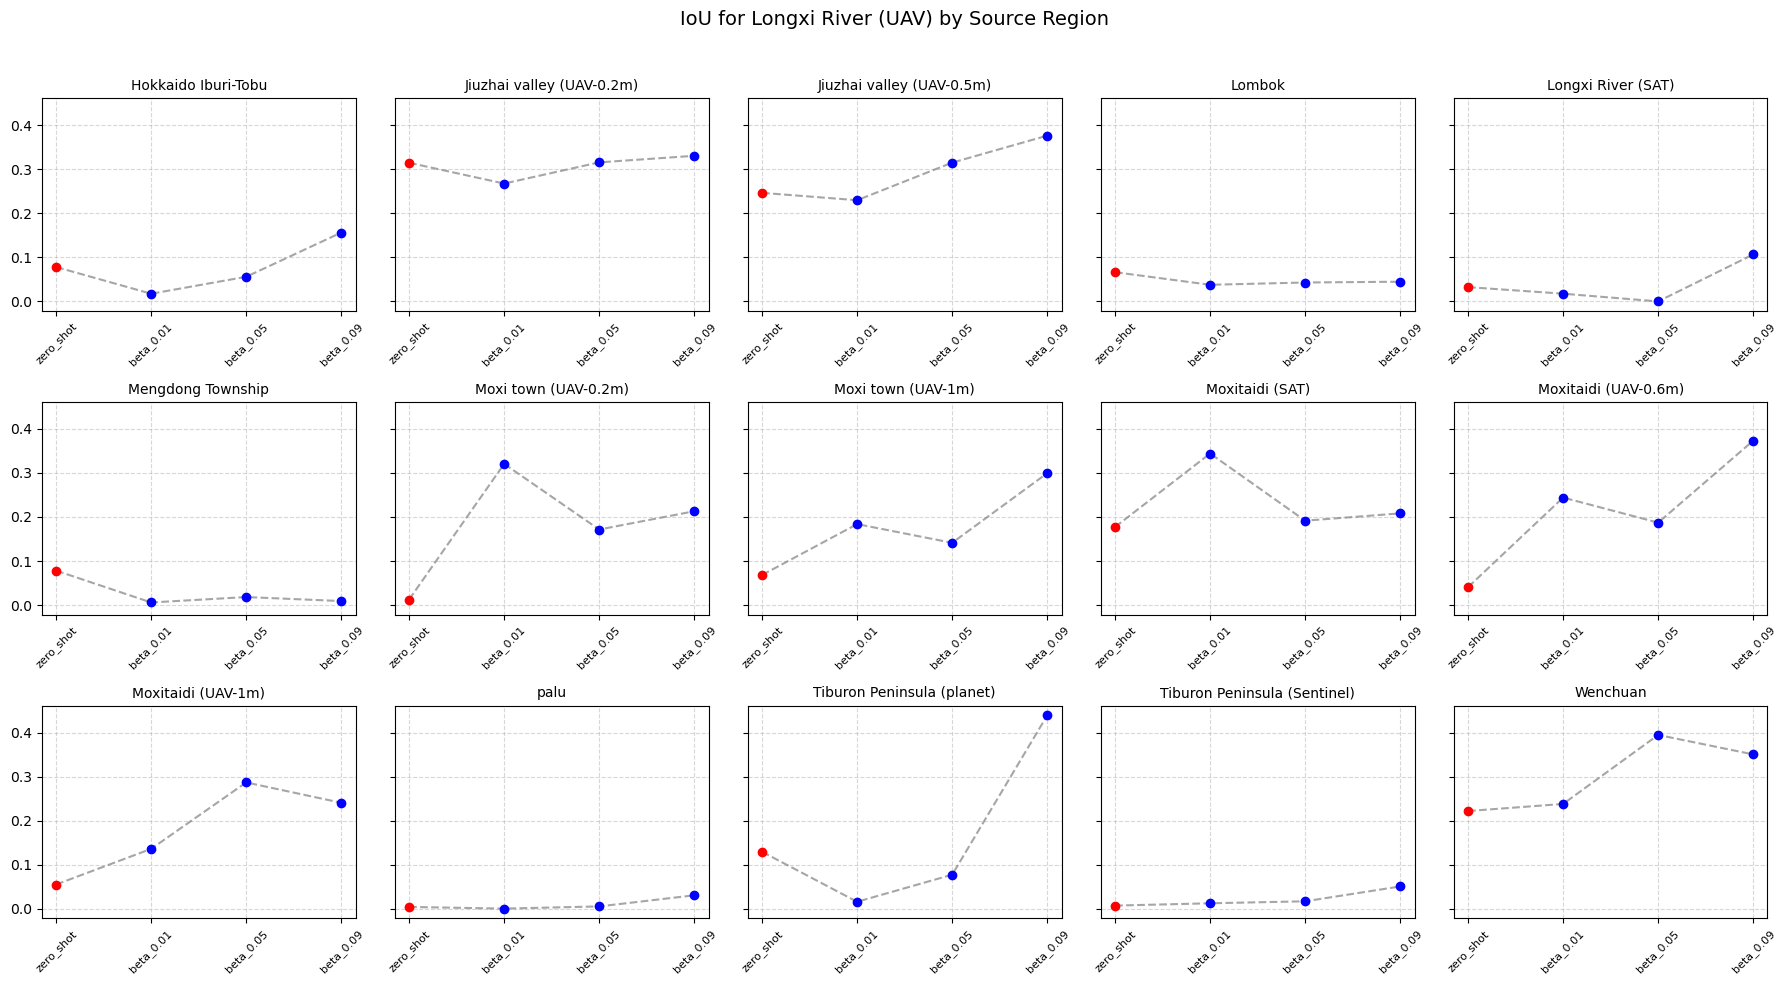

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

files = {
    "zero_shot": "../../results/baseline/source_only_100.csv",
    "beta_0.01": "../../results/new_fda/01.csv",
    "beta_0.05": "../../results/new_fda/05.csv",
    "beta_0.09": "../../results/new_fda/09.csv"
}

dfs = []
for setting, path in files.items():
    df = pd.read_csv(path)
    df = df[df["target_region"] == " Longxi River (UAV)"]
    df = df[["source_region", "iou"]].rename(columns={"iou": setting})
    dfs.append(df)

merged = dfs[0]
for df in dfs[1:]:
    merged = pd.merge(merged, df, on="source_region")


melted = merged.melt(id_vars="source_region", 
                     var_name="setting", 
                     value_name="IoU")

regions = melted["source_region"].unique()
n_regions = len(regions)

cols = 5
rows = (n_regions + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for i, region in enumerate(regions):
    subset = melted[melted["source_region"] == region]
    
    subset = subset.set_index("setting").loc[["zero_shot", "beta_0.01", "beta_0.05", "beta_0.09"]].reset_index()
    
    axes[i].plot(subset["setting"], subset["IoU"], color="gray", linestyle="--", alpha=0.7)
    
    for _, row in subset.iterrows():
        color = "red" if row["setting"] == "zero_shot" else "blue"
        axes[i].plot(row["setting"], row["IoU"], marker="o", color=color)
    
    axes[i].set_title(region, fontsize=10)
    axes[i].set_xticks(subset["setting"].unique())
    axes[i].set_xticklabels(subset["setting"].unique(), rotation=45, fontsize=8)
    axes[i].grid(True, linestyle="--", alpha=0.5)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("IoU for Longxi River (UAV) by Source Region", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

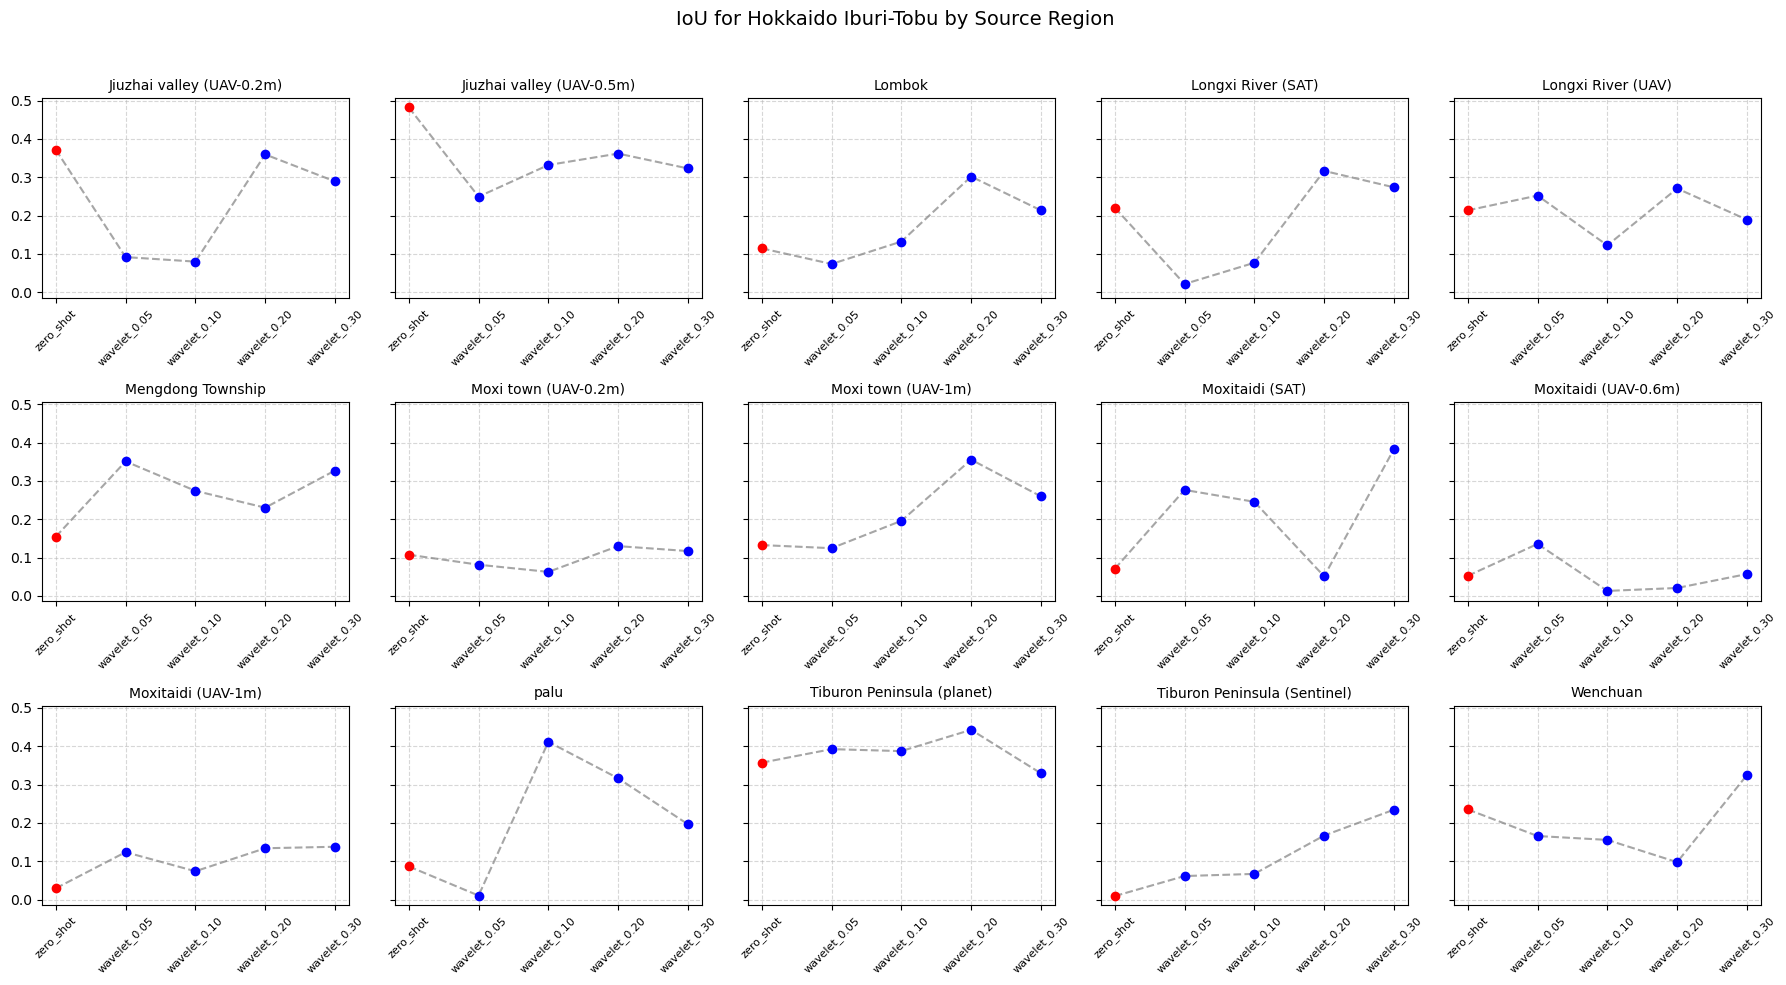

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

files = {
    "zero_shot": "../../results/baseline/source_only_100.csv",
    "wavelet_0.05": "../../results/wavelet/05_replace.csv",
    "wavelet_0.10": "../../results/wavelet/10_replace.csv",
    "wavelet_0.20": "../../results/wavelet/20_replace.csv",
    "wavelet_0.30": "../../results/wavelet/30_replace.csv",
}

dfs = []
for setting, path in files.items():
    df = pd.read_csv(path)
    df = df[df["target_region"] == " Hokkaido Iburi-Tobu"]
    df = df[["source_region", "iou"]].rename(columns={"iou": setting})
    dfs.append(df)

merged = dfs[0]
for df in dfs[1:]:
    merged = pd.merge(merged, df, on="source_region")


melted = merged.melt(id_vars="source_region", 
                     var_name="setting", 
                     value_name="IoU")

regions = melted["source_region"].unique()
n_regions = len(regions)

cols = 5
rows = (n_regions + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for i, region in enumerate(regions):
    subset = melted[melted["source_region"] == region]
    
    subset = subset.set_index("setting").loc[["zero_shot", "wavelet_0.05", "wavelet_0.10", "wavelet_0.20", "wavelet_0.30"]].reset_index()
    
    axes[i].plot(subset["setting"], subset["IoU"], color="gray", linestyle="--", alpha=0.7)
    
    for _, row in subset.iterrows():
        color = "red" if row["setting"] == "zero_shot" else "blue"
        axes[i].plot(row["setting"], row["IoU"], marker="o", color=color)
    
    axes[i].set_title(region, fontsize=10)
    axes[i].set_xticks(subset["setting"].unique())
    axes[i].set_xticklabels(subset["setting"].unique(), rotation=45, fontsize=8)
    axes[i].grid(True, linestyle="--", alpha=0.5)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("IoU for Hokkaido Iburi-Tobu by Source Region", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

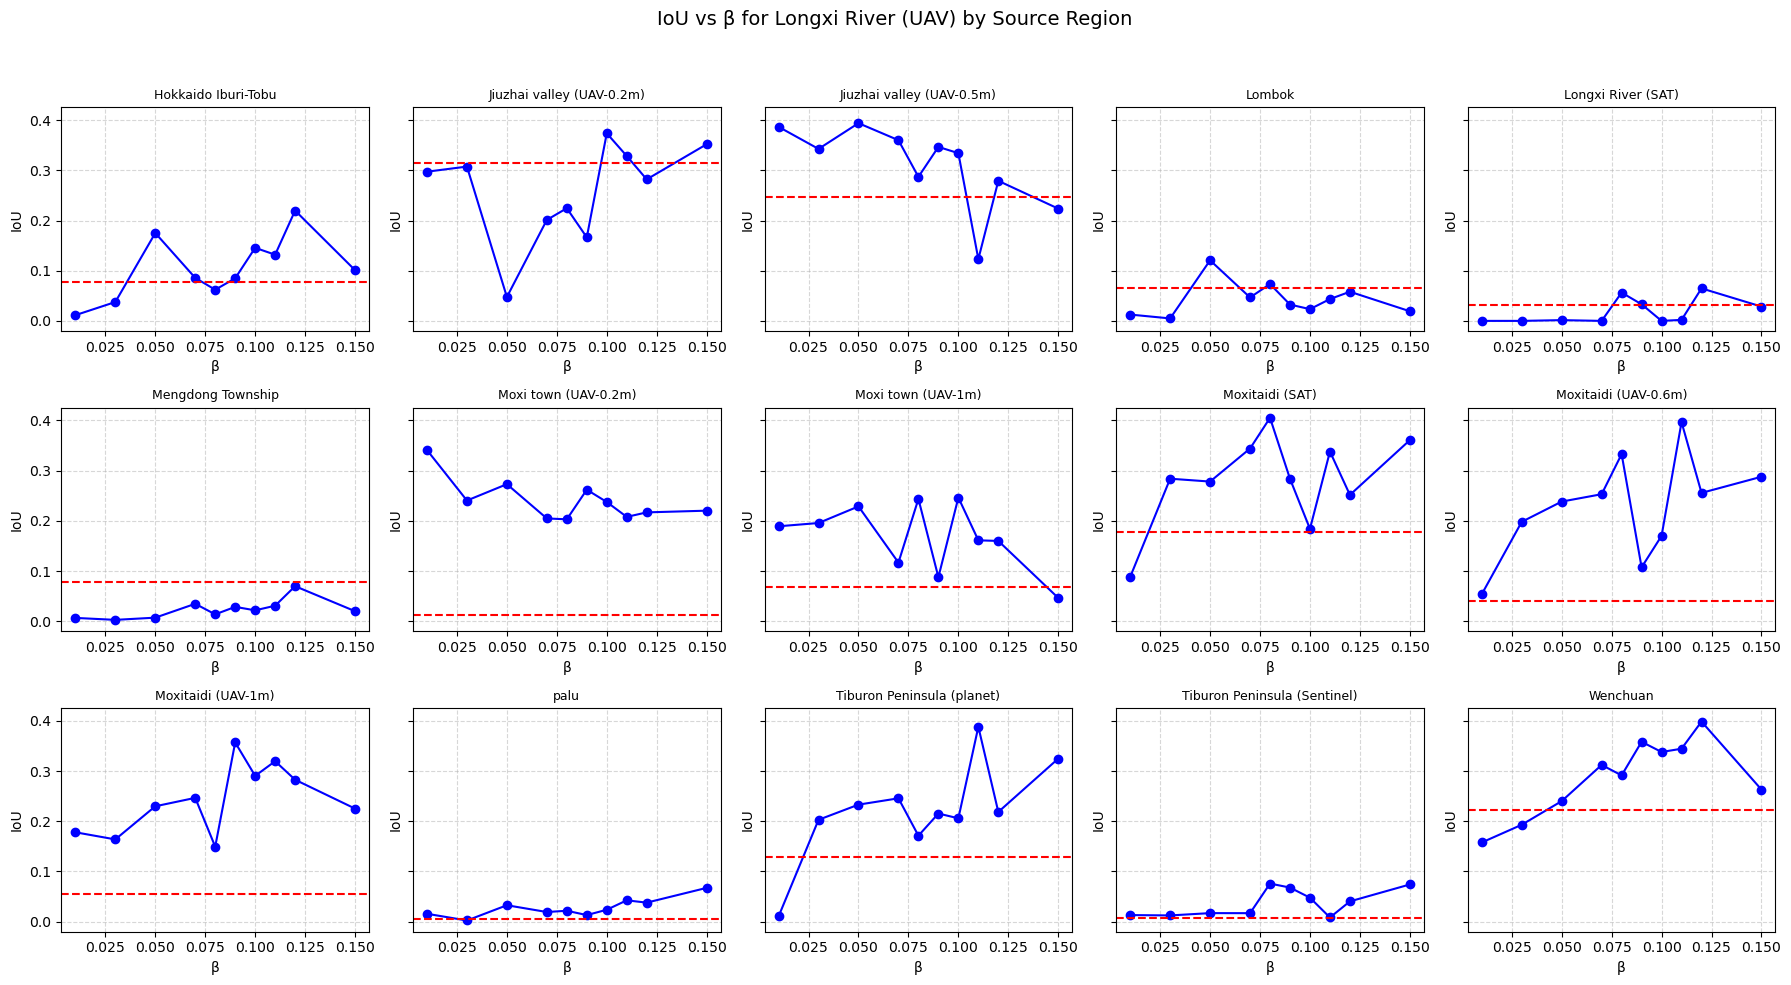

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

baseline_path = "../../results/baseline/source_only_100.csv"
fda_path = "../../results/new_fda/fda_sweep.csv"

base = pd.read_csv(baseline_path)
fda = pd.read_csv(fda_path)

base.columns = base.columns.str.strip()
fda.columns = fda.columns.str.strip()
base["target_region"] = base["target_region"].str.strip()
fda["source_region"] = fda["source_region"].str.strip()

target = "Longxi River (UAV)"

base_longxi = base[base["target_region"] == target][["source_region", "iou"]].rename(columns={"iou": "zero_shot"})

fda_longxi = fda[fda["source_region"].notna()][["beta", "source_region", "iou"]].copy()
fda_longxi["beta"] = pd.to_numeric(fda_longxi["beta"], errors="coerce")

merged = pd.merge(fda_longxi, base_longxi, on="source_region", how="inner")

regions = merged["source_region"].unique()
cols = 5
rows = (len(regions) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for i, region in enumerate(regions):
    subset = merged[merged["source_region"] == region].sort_values("beta")
    axes[i].plot(subset["beta"], subset["iou"], marker="o", color="blue", label="FDA (β sweep)")
    axes[i].axhline(y=subset["zero_shot"].iloc[0], color="red", linestyle="--", label="Zero-shot baseline")
    axes[i].set_title(region, fontsize=9)
    axes[i].set_xlabel("β")
    axes[i].set_ylabel("IoU")
    axes[i].grid(True, linestyle="--", alpha=0.5)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("IoU vs β for Longxi River (UAV) by Source Region", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [12]:
import pandas as pd

fda = pd.read_csv("../../results/new_fda/fda_sweep.csv")
fda.columns = fda.columns.str.strip()

print("Unique FDA target_region values:")
for r in sorted(fda["source_region"].unique()):
    print(f"'{r}'")


Unique FDA target_region values:
' Hokkaido Iburi-Tobu'
' Jiuzhai valley (UAV-0.2m)'
' Jiuzhai valley (UAV-0.5m)'
' Lombok'
' Longxi River (SAT)'
' Mengdong Township'
' Moxi town (UAV-0.2m)'
' Moxi town (UAV-1m)'
' Moxitaidi (SAT)'
' Moxitaidi (UAV-0.6m)'
' Moxitaidi (UAV-1m)'
' Tiburon Peninsula (Sentinel)'
' Tiburon Peninsula (planet)'
' Wenchuan'
' palu'
